**Goal**: My goal for this assignment is to grasp the core concepts of Social Network Analysis (SNA) by exploring the dataset and learn how social media networks are constructed and evaluated.

# Step 1: Download and Load a Stanford SNAP Dataset Subset


For this assignment, I am using the social circles: Facebook dataset from the Stanford Network Analysis Project (SNAP). It maps out the actual friendship networks of anonymized Facebook users.

Here is exactly what the data in the table represents:

•	Nodes (The Numbers): Every unique number in these two columns represents an individual, anonymized Facebook profile.

•	Edges (The Rows): Every row represents a mutual friendship. If a row lists 0 in the Source column and 15 in the Target column, it means User 0 and User 15 are friends on Facebook.

•	The Structure ("Ego Networks"): The dataset was built by selecting specific central users (called "egos") and mapping out all of their friends, as well as the friendships that exist between those friends.

Note: An ego network is defined by whichever person the researcher chooses to focus on, not by the node's label or its total number of connections. "Node 0" is just an arbitrary ID tag the Stanford researchers gave to the very first person they decided to study.


In [4]:
import urllib.request
import pandas as pd

# 1. Download the compressed text file from Stanford SNAP
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
urllib.request.urlretrieve(url, "facebook_combined.txt.gz")

# 2. Read a subset (first 500 rows) directly into a tabular DataFrame
# The dataset is space-separated, has no header, and is gzipped.
df = pd.read_csv(
    "facebook_combined.txt.gz",
    compression='gzip',
    sep=' ',
    header=None,
    nrows=500,
    names=['Source Node', 'Target Node']
)

# 3. Display the first 10 rows of the tabular data
print("Subset of the dataset in tabular form:")
print(df)

Subset of the dataset in tabular form:
     Source Node  Target Node
0              0            1
1              0            2
2              0            3
3              0            4
4              0            5
..           ...          ...
495           10           67
496           10          142
497           10          169
498           10          200
499           10          277

[500 rows x 2 columns]


# Step 2: Exploratory Data Analysis


To explore the "Nodes and Edges" mathematically, we first need to convert your table into a NetworkX graph object.


•	**Defining Nodes and Edges**: the nodes are anonymized Facebook profiles and the edges are friendships.

•	**Directionality (Directed vs. Undirected)**: Facebook dataset is a classic undirected network. If User 0 is friends with User 15, User 15 is automatically friends with User 0. (This contrasts with a directed network like Twitter, where I can follow someone without them following me back).

•	**Edge Weights (Weighted vs. Unweighted)**: this dataset is unweighted. A row simply indicates that a friendship exists (a 1 or a 0); it does not measure whether they are best friends or just distant acquaintances.

•	**Data Representation**:  It shows "edge lists," which is exactly what we displaying with two-column table showing Source and Target nodes.

•	**Visual Structure**: Because this is an "ego network" built around Node 0, we can display a "hub-and-spoke" visual which is a dense cluster centered tightly around one main user.


When created the graph using nx.from_pandas_edgelist(), NetworkX defaulted to building an undirected graph (nx.Graph). This perfectly matches the logic of Facebook that I cannot be friends with someone without them being friends with me. The output will return False, confirming the network is undirected.

In [6]:
import networkx as nx

# 1. Convert your tabular DataFrame (df) into a NetworkX graph object (G)
# This formally defines the columns as entities (nodes) and the rows as relationships (edges)
G = nx.from_pandas_edgelist(df, source='Source Node', target='Target Node')

# 2. Count the total entities and relationships
total_nodes = G.number_of_nodes()
total_edges = G.number_of_edges()
print(f"Total Profiles (Nodes): {total_nodes}")
print(f"Total Friendships (Edges): {total_edges}\n")

# 3. Inspect the Nodes (The Entities)
# We convert the nodes to a list and slice the first 15 to see their format
node_sample = list(G.nodes())[:15]
print("Sample of 15 Nodes:")
print(node_sample)
print(f"Format: Each node is stored as an '{type(node_sample[0]).__name__}' (an integer ID).\n")

# 4. Inspect the Edges (The Relationships)
# We slice the first 5 edges to see how NetworkX stores connections
edge_sample = list(G.edges())[:5]
print("Sample of 5 Edges:")
for edge in edge_sample:
    print(edge)
print("Format: Each edge is stored as a 'tuple' (a paired list) of two node IDs.")

Total Profiles (Nodes): 348
Total Friendships (Edges): 500

Sample of 15 Nodes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Format: Each node is stored as an 'int' (an integer ID).

Sample of 5 Edges:
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(0, 5)
Format: Each edge is stored as a 'tuple' (a paired list) of two node IDs.


In [11]:
import networkx as nx

# 1. Create an Undirected Graph (Default behavior - perfect for Facebook)
G_undirected = nx.from_pandas_edgelist(
    df,
    source='Source Node',
    target='Target Node'
    # create_using=nx.Graph is the hidden default
)

# 2. Creating a Directed Graph (Forced behavior - useful if this were Twitter data)
# Passing nx.DiGraph (Directed Graph) to the create_using parameter
G_directed = nx.from_pandas_edgelist(
    df,
    source='Source Node',
    target='Target Node',
    create_using=nx.DiGraph
)

# 3. Test and compare both
print(f"Is G_undirected directed? {G_undirected.is_directed()}")
print(f"Is G_directed directed? {G_directed.is_directed()}")

Is G_undirected directed? False
Is G_directed directed? True


In [9]:
# Exploratory Data Analysis: Checking Directionality

# Using the built-in NetworkX method to check the graph type
is_directed = G.is_directed()

print(f"Is the graph directed? {is_directed}\n")

# Providing context based on the result
if is_directed:
    print("Conclusion: The relationships are one-way (e.g., following someone on Twitter).")
    print("an edge from Node 0 to Node 15 is NOT the same as Node 15 to Node 0.")
else:
    print("Conclusion: The relationships are two-way and mutual (e.g., Facebook friendships).")
    print("an edge from Node 0 to Node 15 automatically means Node 15 connects back to Node 0.")

Is the graph directed? False

Conclusion: The relationships are two-way and mutual (e.g., Facebook friendships).
an edge from Node 0 to Node 15 automatically means Node 15 connects back to Node 0.


In [13]:
# Exploratory Data Analysis: Checking Edge Weights

# 1. Pulling the first edge, making NetworkX to include its data dictionary
sample_edge_data = list(G.edges(data=True))[0]

print("Sample Edge with its data dictionary attached:")
print(sample_edge_data)
print("\n")

# 2. Checking if a 'weight' attribute exists in that dictionary
node_A, node_B, attributes = sample_edge_data
is_weighted = 'weight' in attributes

print(f"Are there weights assigned to these edges? {is_weighted}\n")

# 3. Providing context
if is_weighted:
    print("Conclusion: The network is weighted. Connections have varying strengths.")
else:
    print("Conclusion: The network is unweighted. A friendship either exists or it doesn't.")
    print("There is no data to tell us who is a 'best friend' versus a 'distant acquaintance'.")

Sample Edge with its data dictionary attached:
(0, 1, {})


Are there weights assigned to these edges? False

Conclusion: The network is unweighted. A friendship either exists or it doesn't.
There is no data to tell us who is a 'best friend' versus a 'distant acquaintance'.


Visualizing Ego Network using Hub and Spoke Visual: Node 0 sitting in the center or acting as a massive anchor, with lines radiating out to nodes 1 through 100, forming a dense star or web shape.

The Hub: Node 0 acts as the massive central anchor.

The Spokes: All other nodes (1 through 100+) are radiating outward from Node 0. They are only included in this specific subset because of their relationship to that central user.

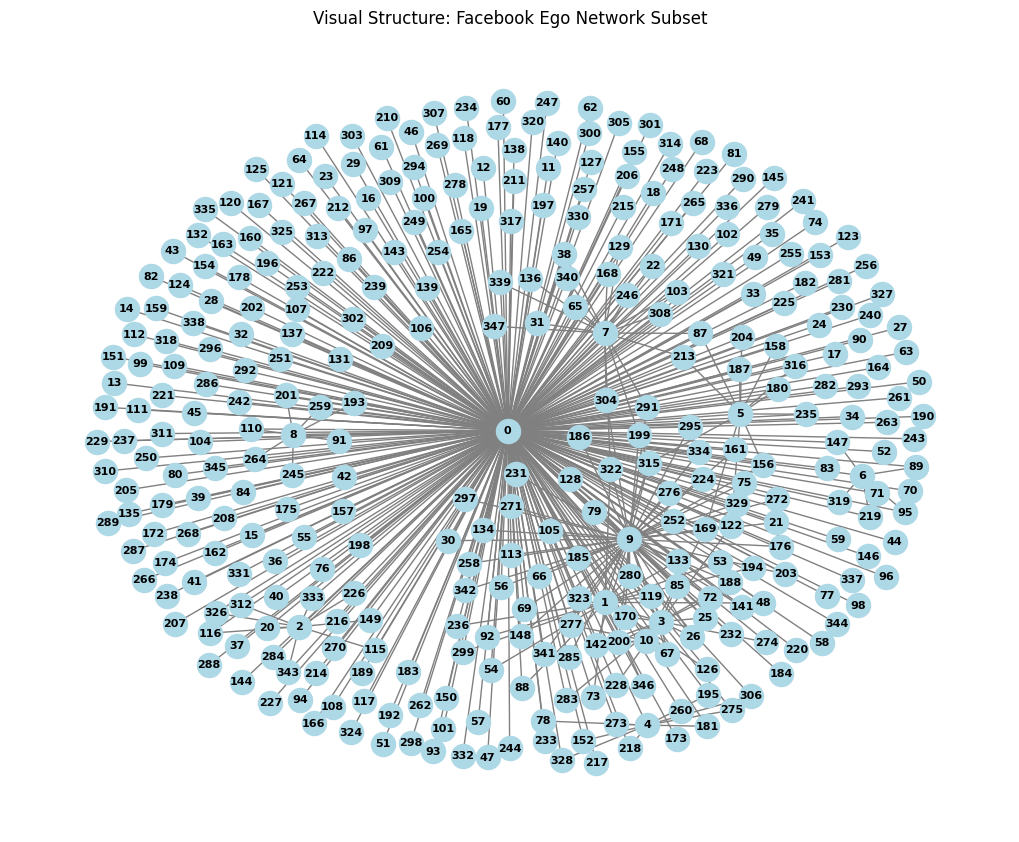

In [12]:
import matplotlib.pyplot as plt

# 1. Setting the size of the canvas
plt.figure(figsize=(10, 8))

# 2. Drawing the undirected graph (G_undirected)
# Adding styling parameters to make the nodes and edges visible
nx.draw(
    G_undirected,
    with_labels=True,
    node_color="lightblue",
    node_size=300,
    font_size=8,
    font_weight="bold",
    edge_color="gray"
)

# 3. Adding a title and render the plot
plt.title("Visual Structure: Facebook Ego Network Subset")
plt.show()

For EDA we will now perform following task to understand the concepts of SNA chapter 2.

•	**Network Size and Density**: Count the total number of nodes (people) and edges (friendships). Density tells you what fraction of all possible friendships actually exist. In an ego network, density is often higher than a random network because everyone shares at least one mutual connection (the ego).

•	**Degree and Average Degree**: "Degree" is simply the number of friends a specific node has. Calculating the average degree tells how many friends a typical person in 500-edge subset has.

•	**Adjacency Matrix**: This is the mathematical representation of who is connected to whom, forming a grid of 1s and 0s.

•	**Shortest Paths and Graph Diameter**: This measures distance in the network. The diameter is the longest "shortest path" between any two people.

•	**Degree Centrality**: "Who is the most popular or influential person here?" It ranks nodes by their total number of connections.

•	**Clustering Coefficient**: It calculates tight-knit group of people, whether the friends of a person are also friends with each other, forming tight triangles of mutual connections.


In [24]:
# 1. Network Size (Counting nodes and edges)
num_nodes = G_undirected.number_of_nodes()
num_edges = G_undirected.number_of_edges()

print("--- Network Size ---")
print(f"Total Nodes (People): {num_nodes}")
print(f"Total Edges (Friendships): {num_edges}\n")

# 2. Network Density (Ratio of actual vs. possible connections)
density = nx.density(G_undirected)

print("--- Network Density ---")
print(f"Density Score: {density:.4f}")
print(f"This means {(density * 100):.2f}% of all possible friendships in this specific group actually exist.")

--- Network Size ---
Total Nodes (People): 348
Total Edges (Friendships): 500

--- Network Density ---
Density Score: 0.0083
This means 0.83% of all possible friendships in this specific group actually exist.


In an undirected network, the formula to find the maximum number of potential connections is:

Potential Edges: N*(N - 1)/2

total number of nodes (348).

348 * 347 = 120,756
120,756 / 2 = 60,378

The (N - 1) in the density formula accounts for the fact that a person cannot be friends with themselves.If there are N people in the network, any single person can only potentially connect with the other individuals in the group. In this dataset of 348 people, one person can have a maximum of 347 friends.When we multiply N * (N-1), we are calculating the total number of connections if every single person friended everyone else. We then divide that total by 2 because this is an undirected network; a friendship between Person A and Person B is the exact same relationship as Person B and Person A, so dividing by 2 ensures we do not count the same mutual friendship twice.

In [18]:
# 1. Calculating Individual Degrees
# We create a dictionary of all nodes and their connection counts
node_degrees = dict(G_undirected.degree())

# Sorting the dictionary to find the most connected people in the subset
sorted_degrees = sorted(node_degrees.items(), key=lambda item: item[1], reverse=True)

print("--- Top 5 Most Connected Nodes ---")
for node, degree in sorted_degrees[:5]:
    print(f"Node {node} has {degree} connections")
print("\n")

# 2. Calculating Average Degree
# In an undirected graph, each edge connects two nodes, so it counts twice toward the total degree.
# Formula: (2 * Total Edges) / Total Nodes
total_edges = G_undirected.number_of_edges()
total_nodes = G_undirected.number_of_nodes()

print(f"Total Edges: {total_edges}")
print(f"Total Nodes: {total_nodes}\n")

average_degree = (2 * total_edges) / total_nodes

print("--- Average Degree ---")
print(f"Average Degree: {average_degree:.2f}")


--- Top 5 Most Connected Nodes ---
Node 0 has 347 connections
Node 9 has 57 connections
Node 7 has 20 connections
Node 1 has 17 connections
Node 3 has 17 connections


Total Edges: 500
Total Nodes: 348

--- Average Degree ---
Average Degree: 2.87


An adjacency matrix is a mathematical grid that maps out every single connection in the network. Since we have 348 nodes, we will create a 348 by 348 grid.

In [19]:
# Exploratory Data Analysis: The Adjacency Matrix

# 1. Converting the NetworkX graph into an Adjacency Matrix using pandas
adj_matrix = nx.to_pandas_adjacency(G_undirected)

# 2. Printing a 10x10 sample of the grid to inspect its structure
print("--- Adjacency Matrix (10x10 Sample) ---")
print(adj_matrix.iloc[:10, :10])
print("\n")

# 3. Printing the full dimensions to confirm its size
print(f"Full Matrix Shape: {adj_matrix.shape[0]} rows by {adj_matrix.shape[1]} columns")

--- Adjacency Matrix (10x10 Sample) ---
     0    1    2    3    4    5    6    7    8    9
0  0.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
1  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
3  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0
4  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
5  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
6  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
7  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
8  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
9  1.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0


Full Matrix Shape: 348 rows by 348 columns


We see a path [1, 0, 277]. This means Node 1 is not direct friends with Node 277, but they are both friends with Node 0.

Because Node 0 acts as a massive central bridge connecting almost everyone in this specific dataset subset, the maximum number of hops required to connect any two people is usually just 2 (Friend A goes through Node 0 to reach Friend B). Therefore, the graph diameter is 2.

The mathematical formula for graph diameter only works if a valid path exists between every single person in the network. If even one person in your dataset is completely isolated or forms a disconnected mini-group, the number of hops required to reach them is technically infinite. Because Python cannot calculate an "infinite" path length, NetworkX will immediately crash and throw a NetworkXError.

In [20]:
# Exploratory Data Analysis: Shortest Paths and Graph Diameter

# 1. Shortest Path Example
# mapping the connection between Node 1 and Node 277
path = nx.shortest_path(G_undirected, source=1, target=277)
path_length = nx.shortest_path_length(G_undirected, source=1, target=277)

print("--- Shortest Path Example ---")
print(f"Path from Node 1 to Node 277: {path}")
print(f"Total Hops: {path_length}\n")

# 2. Graph Diameter
# We must isolate the largest connected group first. If even one person
# is completely isolated, the diameter mathematically breaks and returns an error.
largest_cc = max(nx.connected_components(G_undirected), key=len)
G_connected = G_undirected.subgraph(largest_cc)

diameter = nx.diameter(G_connected)

print("--- Graph Diameter ---")
print(f"Overall Graph Diameter: {diameter}")

--- Shortest Path Example ---
Path from Node 1 to Node 277: [1, 0, 277]
Total Hops: 2

--- Graph Diameter ---
Overall Graph Diameter: 2


In [21]:
# Exploratory Data Analysis: Degree Centrality

# 1. Calculating degree centrality for all nodes
# This returns a dictionary where keys are nodes and values are centrality scores (0.0 to 1.0)
centrality = nx.degree_centrality(G_undirected)

# 2. Sorting the nodes to find the most central people
sorted_centrality = sorted(centrality.items(), key=lambda item: item[1], reverse=True)

# 3. Printing the top 5 most central nodes
print("--- Top 5 Nodes by Degree Centrality ---")
for node, cent_score in sorted_centrality[:5]:
    # We multiply by 100 to make the decimal easier to read as a percentage
    print(f"Node {node}: {cent_score:.4f} (Connected to {(cent_score * 100):.2f}% of the network)")

--- Top 5 Nodes by Degree Centrality ---
Node 0: 1.0000 (Connected to 100.00% of the network)
Node 9: 0.1643 (Connected to 16.43% of the network)
Node 7: 0.0576 (Connected to 5.76% of the network)
Node 1: 0.0490 (Connected to 4.90% of the network)
Node 3: 0.0490 (Connected to 4.90% of the network)


In [23]:
# Exploratory Data Analysis: Clustering Coefficient

# 1. Local Clustering Coefficient (Focusing on Node 0)
# We calculate the specific clustering score for the network's central ego
node_0_clustering = nx.clustering(G_undirected, 0)

print("--- Local Clustering Coefficient ---")
print(f"Node 0: {node_0_clustering:.4f}")
print(f"This means {(node_0_clustering * 100):.2f}% of Node 0's friends are also friends with each other.\n")

# 2. Average Clustering Coefficient (Entire Network)
# This calculates the score for every single person and finds the network-wide average
avg_clustering = nx.average_clustering(G_undirected)

print("--- Average Clustering Coefficient ---")
print(f"Network Average: {avg_clustering:.4f}")
print("This gives us the overall tight-knit group of people of this specific 348-person subset.")


--- Local Clustering Coefficient ---
Node 0: 0.0025
This means 0.25% of Node 0's friends are also friends with each other.

--- Average Clustering Coefficient ---
Network Average: 0.3334
This gives us the overall tight-knit group of people of this specific 348-person subset.


In [26]:
import networkx as nx
from google.colab import files

# 1. Exporting the network to a GraphML file (Gephi's native format)
nx.write_graphml(G_undirected, "facebook_ego_network.graphml")

# 2. Trigger the download to local machine
files.download("facebook_ego_network.graphml")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>